# 08 · Representation x complexity matching, and epistasis (mechanistic closure)

**Role in the story**: `06` found that **esm_lr (strong representation + simple linear model) is
most robust OOD**. This chapter explains "why exactly this combination" from two mechanistic angles
and answers two reviewer concerns:

1. **Representation x complexity matching (Q1)**: could it be the "simple model" rather than the
   "strong representation" doing the work? Can binary, given enough regularization, catch up to ESM?
   — Conclusion: after fair tuning, the **ESM ceiling still exceeds binary**; and a neat **crossover**
   emerges: binary's best partner is XGB (sparse encoding needs nonlinearity to mine interactions),
   ESM's best partner is LR (the dense representation already carries higher-order information).
2. **Epistasis (Q5)**: HIV resistance is often mutation synergy (nonlinear). Can adding explicit
   pairwise interaction terms to binary catch up to ESM under OOD? — Conclusion: explicit
   interactions are **harmful** under OOD (gain_int mostly negative); esm_lr steadily beats
   binary+interaction -> **ESM has implicitly encoded epistasis and generalizes better**; a linear
   classifier suffices.

Together these explain `05` (fusion useless) and `06` (esm_lr most robust): the ESM representation
encodes mutation synergy implicitly into a dense vector, and a simple linear model can exploit it
without overfitting the training distribution.

**Difference from the original paper (figure constraint)**: no such analysis in the original paper.
We use a regularization-OOD curve (representation x complexity crossover), an epistasis
interaction-gain bar (mostly negative), and a 2D projection of the P82xP90 case in ESM space.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "work" / "prepared").exists() else CWD.parent
assert (PROJECT_ROOT / "work" / "prepared").exists(), f"cannot locate work/prepared from {CWD}"

WR = PROJECT_ROOT / "work" / "results"
RESULTS_DIR = PROJECT_ROOT / "results" / "notebooks" / "08_complexity"
FIG_DIR = PROJECT_ROOT / "figures" / "mutation_aware" / "08_complexity"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("project root:", PROJECT_ROOT)

project root: /mnt/d/我的项目/生信包复现重构升级/projects/1模型推理型/变异-耐药性预测/HIV-ESM-2


In [2]:
SURFACE, INK, INK2, INK3, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1"
CLASS_ORDER = ["PI", "NRTI", "NNRTI"]
CLASS_COLOR = {"PI": "#2a78d6", "NRTI": "#1baf7a", "NNRTI": "#eda100"}
COMBO_COLOR = {
    ("binary", "LR"): "#8a8984", ("binary", "XGB"): "#eb6834",
    ("esm", "LR"): "#2a78d6", ("esm", "XGB"): "#4a3aa7",
}
POS, NEG = "#d03b3b", "#2a78d6"
GROUP_COLOR = {"WT": "#8a8984", "only_82": "#2a78d6", "only_90": "#eda100", "both": "#d03b3b"}
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 11, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2, "axes.grid": False,
    "font.family": "DejaVu Sans",
})
print("palette ready")

palette ready


## 1 · Load the Q1 regularization sweep and Q5 epistasis results

In [3]:
q1 = pd.read_csv(WR / "probe_q1_regularization.csv")
q5 = pd.read_csv(WR / "probe_q5_epistasis.csv")
case = pd.read_csv(WR / "probe_q5_casestudy_pr.csv")

best = (q1.loc[q1.groupby(["rep", "clf"])["ood_cluster_18"].idxmax()]
        [["rep", "clf", "param", "ood_subtype_PI", "ood_cluster_18"]]
        .reset_index(drop=True))
best.to_csv(RESULTS_DIR / "q1_best_by_combo.csv", index=False)
print("representation x complexity: fairly-tuned cluster-OOD ceiling per rep x clf")
best

representation x complexity: fairly-tuned cluster-OOD ceiling per rep x clf


,rep,clf,param,ood_subtype_PI,ood_cluster_18
0,binary,LR,0.01,0.875579,0.910739
1,binary,XGB,3.00,0.874265,0.921100
2,esm,LR,0.01,0.885707,0.932546
3,esm,XGB,4.00,0.860779,0.907293


In [4]:
q5_summary = {
    "mean_gain_int_all": round(q5["gain_int"].mean(), 4),
    "mean_gain_int_scarce": round(q5[q5["scarce"]]["gain_int"].mean(), 4),
    "mean_esm_vs_int": round(q5["esm_vs_int"].mean(), 4),
    "mean_esm_lr_vs_xgb": round(q5["esm_lr_vs_xgb"].mean(), 4),
    "n_drugs_gain_int_negative": int((q5["gain_int"] < 0).sum()),
}
pd.Series(q5_summary).to_csv(RESULTS_DIR / "q5_summary.csv", header=["value"])
print(q5_summary)

{'mean_gain_int_all': -0.0143, 'mean_gain_int_scarce': -0.031, 'mean_esm_vs_int': 0.0361, 'mean_esm_lr_vs_xgb': 0.0266, 'n_drugs_gain_int_negative': 17}


## 2 · Figure 1: representation x complexity matching (Q1)

Fairly-tuned cluster-OOD ceilings for the four rep x clf combinations. **Reading: esm+LR is
highest; binary prefers XGB, esm prefers LR — dense representation with a simple model, sparse
encoding with nonlinearity, forming a crossover.**

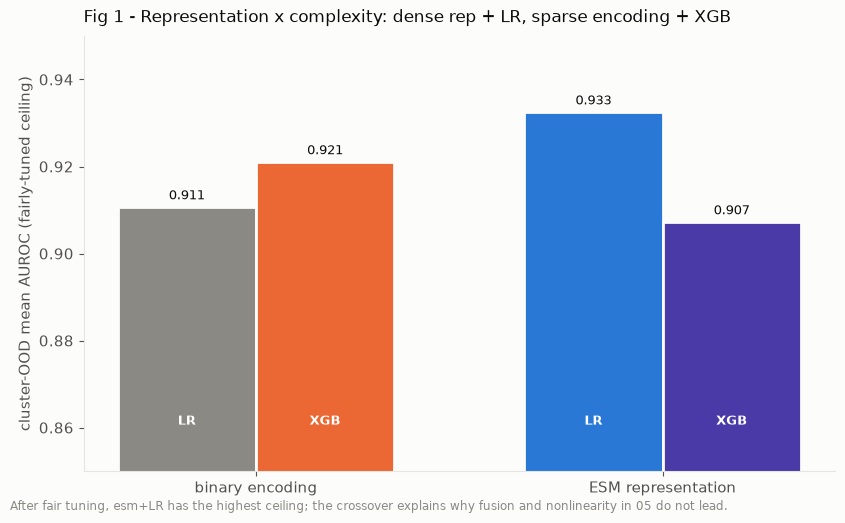

saved representation_complexity_matching.png


In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
reps = ["binary", "esm"]; clfs = ["LR", "XGB"]
xpos = {"binary": 0, "esm": 1}
width = 0.34
for j, clf in enumerate(clfs):
    xs = [xpos[r] + (j - 0.5) * width for r in reps]
    ys = [float(best[(best["rep"] == r) & (best["clf"] == clf)]["ood_cluster_18"].iloc[0]) for r in reps]
    for x, y, r in zip(xs, ys, reps):
        ax.bar(x, y, width=width, color=COMBO_COLOR[(r, clf)], edgecolor=SURFACE, lw=2, zorder=2)
        ax.text(x, y + 0.001, f"{y:.3f}", ha="center", va="bottom", color=INK, fontsize=9.5)
        ax.text(x, 0.86, clf, ha="center", va="bottom", color="#fff", fontsize=9, fontweight="bold")
ax.set_xticks([0, 1]); ax.set_xticklabels(["binary encoding", "ESM representation"])
ax.set_ylabel("cluster-OOD mean AUROC (fairly-tuned ceiling)")
ax.set_ylim(0.85, 0.95)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.set_title("Fig 1 - Representation x complexity: dense rep + LR, sparse encoding + XGB", loc="left", color=INK, fontsize=12, pad=10)
fig.text(0.01, 0.005, "After fair tuning, esm+LR has the highest ceiling; the crossover explains why fusion and nonlinearity in 05 do not lead.",
         color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "representation_complexity_matching.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved representation_complexity_matching.png")

## 3 · Figure 2: OOD gain of explicit epistasis interactions (Q5)

Per drug, `gain_int = binary+interaction - binary` (cluster OOD). **Reading: almost all negative** —
explicit pairwise interactions learned within a training cluster fail on a new cluster, i.e. they
overfit the training distribution. Annotated with esm_lr's mean lead over binary+interaction.

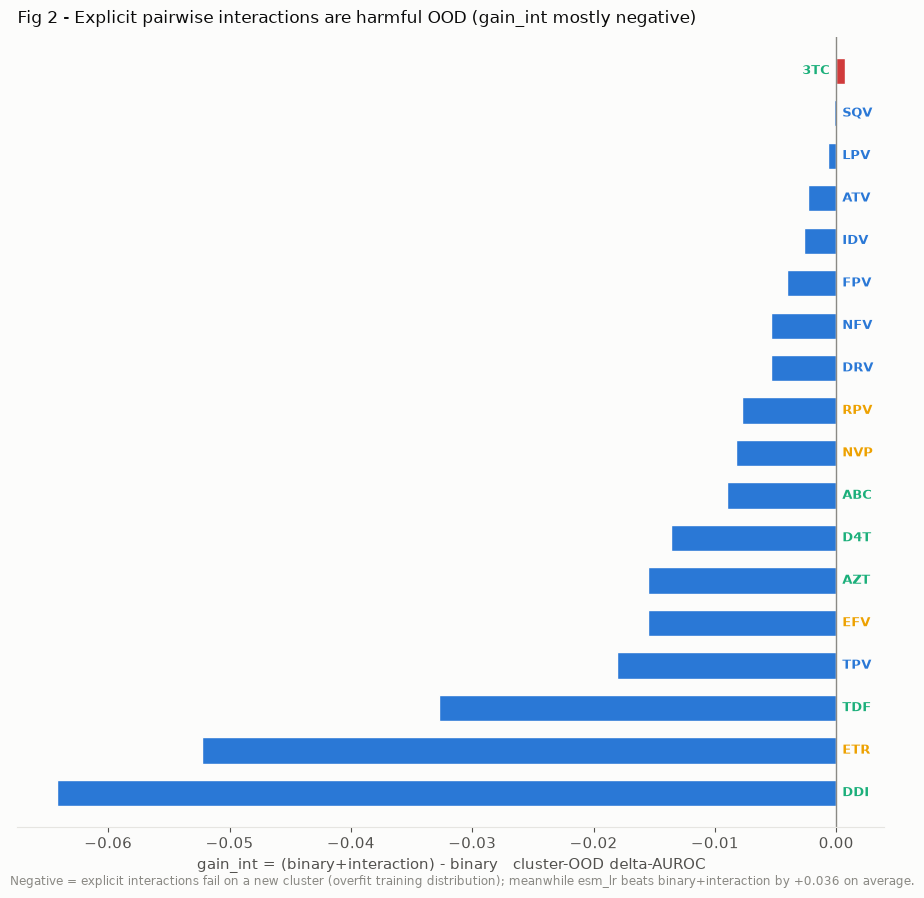

saved epistasis_interaction_gain.png


In [6]:
q5s = q5.sort_values("gain_int").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 0.42 * len(q5s) + 1.4))
for i, r in q5s.iterrows():
    c = POS if r["gain_int"] >= 0 else NEG
    ax.barh(i, r["gain_int"], color=c, height=0.62, edgecolor=SURFACE)
    ax.text(-0.0005 if r["gain_int"] >= 0 else 0.0005, i, r["drug"],
            va="center", ha="right" if r["gain_int"] >= 0 else "left",
            color=CLASS_COLOR[r["class"]], fontsize=9, fontweight="bold")
ax.axvline(0, color=INK3, lw=1)
ax.set_yticks([])
ax.set_xlabel("gain_int = (binary+interaction) - binary   cluster-OOD delta-AUROC")
ax.set_ylim(-0.8, len(q5s) - 0.2)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
mean_evi = q5["esm_vs_int"].mean()
ax.set_title("Fig 2 - Explicit pairwise interactions are harmful OOD (gain_int mostly negative)", loc="left", color=INK, fontsize=12, pad=10)
fig.text(0.01, 0.005, f"Negative = explicit interactions fail on a new cluster (overfit training distribution); meanwhile esm_lr beats binary+interaction by {mean_evi:+.3f} on average.",
         color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "epistasis_interaction_gain.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved epistasis_interaction_gain.png")

## 4 · Figure 3: ESM-space projection of the P82 x P90 epistasis case

The classic PI resistance synergy pair V82A x L90M in PR. Group sequences into {wild-type / only82 /
only90 / double mutant} and plot the 2D projection of their ESM mean representation (PCA coordinates
from `probe_q5_casestudy_pr.csv`). **Reading: the four groups are separable in representation space**
— i.e. ESM implicitly encodes the difference between single and double mutations.

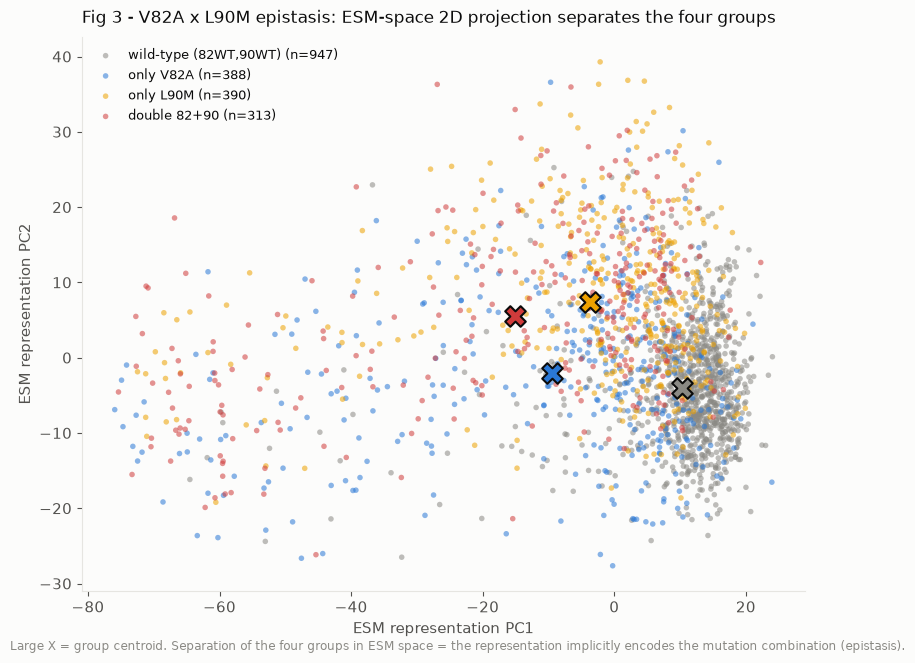

saved epistasis_case_projection.png


In [7]:
fig, ax = plt.subplots(figsize=(8.2, 6.6))
label_map = {"WT": "wild-type (82WT,90WT)", "only_82": "only V82A", "only_90": "only L90M", "both": "double 82+90"}
order = ["WT", "only_82", "only_90", "both"]
for g in order:
    sub = case[case["group"] == g]
    ax.scatter(sub["pc1"], sub["pc2"], s=16, color=GROUP_COLOR[g], alpha=0.55,
               edgecolor="none", label=f"{label_map[g]} (n={len(sub)})")
    if len(sub):
        ax.scatter(sub["pc1"].mean(), sub["pc2"].mean(), s=220, color=GROUP_COLOR[g],
                   edgecolor=INK, lw=1.5, marker="X", zorder=3)
ax.set_xlabel("ESM representation PC1"); ax.set_ylabel("ESM representation PC2")
ax.legend(frameon=False, loc="best", fontsize=9)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.set_title("Fig 3 - V82A x L90M epistasis: ESM-space 2D projection separates the four groups", loc="left", color=INK, fontsize=12, pad=10)
fig.text(0.01, 0.005, "Large X = group centroid. Separation of the four groups in ESM space = the representation implicitly encodes the mutation combination (epistasis).",
         color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "epistasis_case_projection.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved epistasis_case_projection.png")

## 5 · Summary (mechanistic closure)

- **Representation x complexity matching**: after fair tuning, esm+LR has the highest cluster-OOD
  ceiling (~0.9325 > binary+XGB ~0.9211); and the crossover (binary prefers XGB, esm prefers LR)
  explains why neither fusion nor nonlinearity leads in `05`.
- **Epistasis**: explicit pairwise interactions are almost all negative-gain under OOD (overfit the
  training distribution), while esm_lr steadily beats binary+interaction -> **ESM has implicitly
  encoded mutation synergy and generalizes better than freshly-learned explicit interactions**.
- **Case study**: the four V82A x L90M groups are separable in ESM space, directly corroborating
  implicit epistasis encoding.
- **Closure**: `05` (fusion useless) + `06` (esm_lr most robust) + `07` (attends to DRMs) + `08`
  (implicit epistasis encoding, strong rep + simple model) together support the thesis — PLM value
  lies in OOD generalization, and "strong representation + simple linear model" is the correct usage.

**Next**: `00` (project overview) and `09` (manuscript figure aggregation) to wrap up.